<a href="https://colab.research.google.com/github/rgg2023/sp500-return-prediction/blob/preprocessing/preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- [Step 1] Standard Data Science Libraries Imported Successfully ---

--- [Step 2] Raw Data Information ---
         date   open   high    low  close    volume Name
0  2013-02-08  15.07  15.12  14.63  14.75   8407500  AAL
1  2013-02-11  14.89  15.01  14.26  14.46   8882000  AAL
2  2013-02-12  14.45  14.51  14.10  14.27   8126000  AAL
3  2013-02-13  14.30  14.94  14.25  14.66  10259500  AAL
4  2013-02-14  14.94  14.96  13.16  13.99  31879900  AAL
Dataset Shape: (619040, 7)

--- [Step 3] Missing Values & Outliers Preprocessing ---
Missing Values Before Treatment:

date       0
open      11
high       8
low        8
close      0
volume     4
Name       0
dtype: int64
-> Missing value treatment and outlier clipping completed.

--- [Step 4] Categorical Value Encoding ---
-> Label encoding for ticker symbols completed.

--- [Step 5] Splitting the Dataset ---
Training Set Shape: (467401, 5)
Test Set Shape: (139007, 5)

--- [Step 6] Feature Scaling ---
-> Feature scaling completed.

--- [Ste

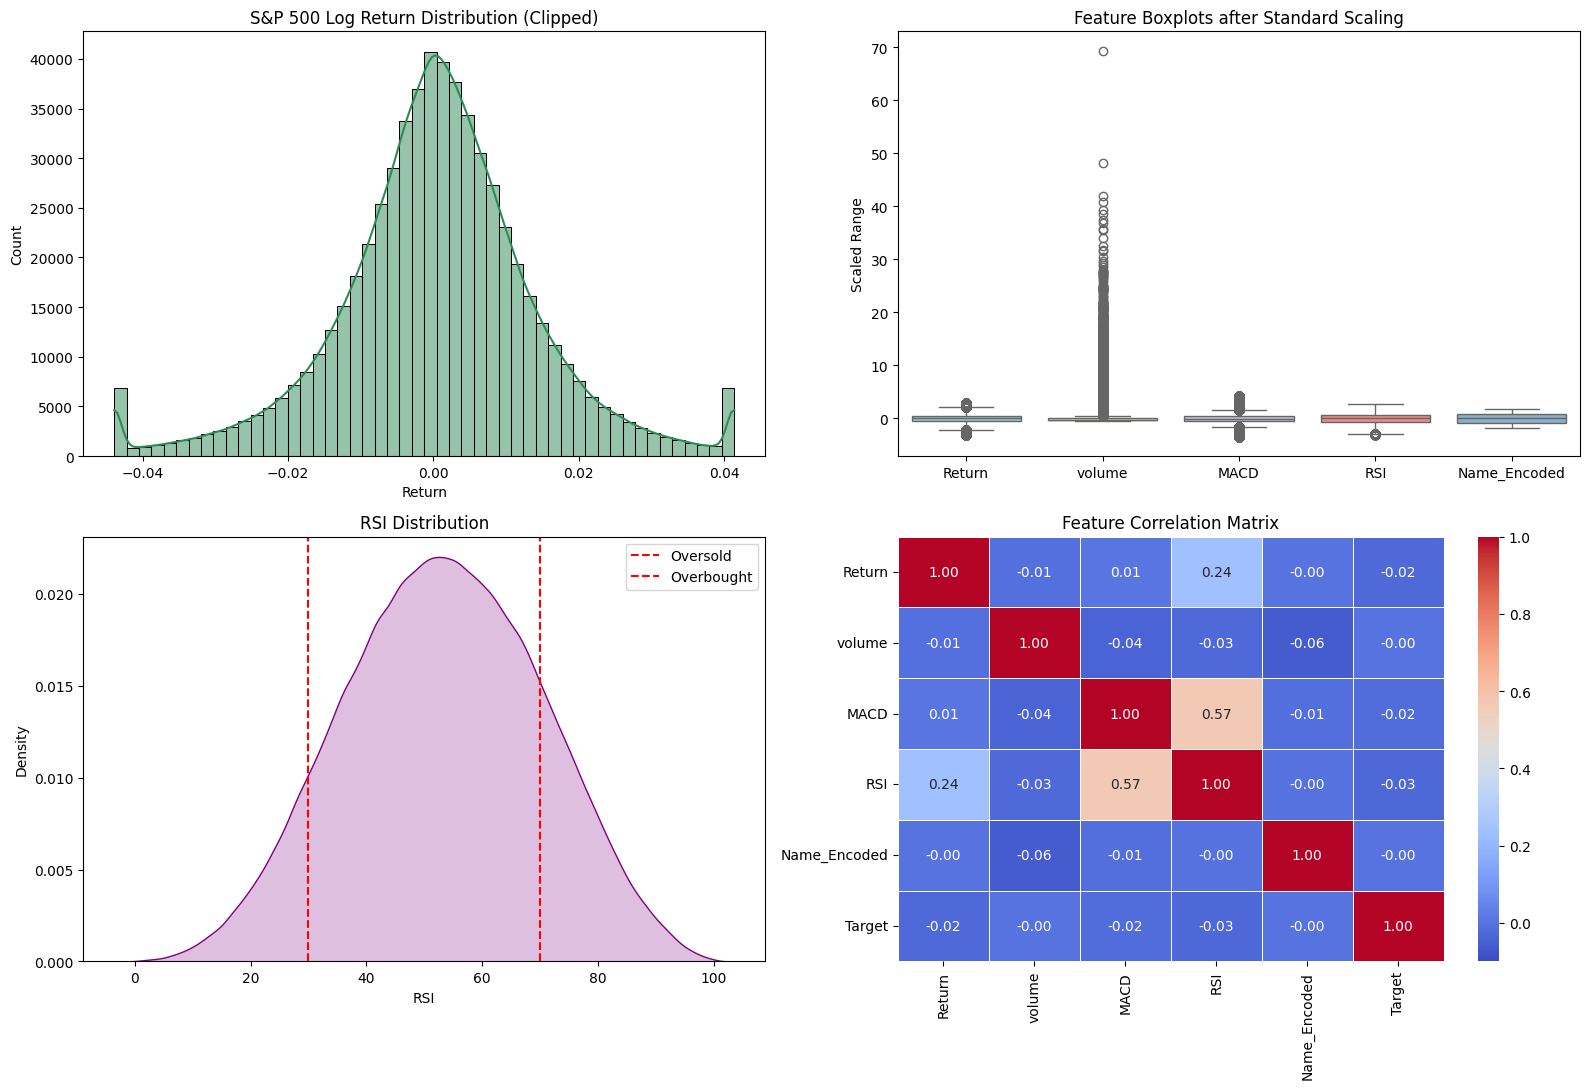


--- End-to-End Preprocessing Pipeline Finished ---


In [2]:
# ====================================================
# [Step 1] 라이브러리 임포트 (Import the Libraries)
# ====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder

import warnings
warnings.filterwarnings('ignore')

print("--- [Step 1] Standard Data Science Libraries Imported Successfully ---")


# ====================================================
# [Step 2] 데이터셋 임포트 (Import the Dataset)
# ====================================================
df = pd.read_csv('all_stocks_5yr.csv')

print("\n--- [Step 2] Raw Data Information ---")
print(df.head(5))
print(f"Dataset Shape: {df.shape}")


# ====================================================
# [Step 3] 결측치 및 이상치 정제
# ====================================================
print("\n--- [Step 3] Missing Values & Outliers Preprocessing ---")

df = df.copy()

# 거래량(volume) 0값 -> NaN 처리
df['volume'] = df['volume'].replace(0, np.nan)

# 결측치 확인
print("Missing Values Before Treatment:\n")
print(df.isnull().sum())

# close forward fill
df['close'] = df.groupby('Name')['close'].ffill()

# volume 평균값 대체
df['volume'] = df.groupby('Name')['volume'].transform(
    lambda x: x.fillna(x.mean())
)

# ====================================================
# 금융 피처 엔지니어링
# ====================================================

# 로그 수익률(Log Return)
df['Return'] = df.groupby('Name')['close'].transform(
    lambda x: np.log(x / x.shift(1))
)

# 이동평균
df['MA_12'] = df.groupby('Name')['close'].transform(
    lambda x: x.rolling(window=12).mean()
)

df['MA_26'] = df.groupby('Name')['close'].transform(
    lambda x: x.rolling(window=26).mean()
)

# MACD
df['MACD'] = df['MA_12'] - df['MA_26']


# RSI 계산 함수
def calculate_rsi(series, period=14):

    delta = series.diff()

    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()

    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()

    rs = gain / (loss + 1e-9)

    rsi = 100 - (100 / (1 + rs))

    return rsi


# RSI 생성
df['RSI'] = df.groupby('Name')['close'].transform(
    lambda x: calculate_rsi(x)
)

# ====================================================
# 분류 타겟 생성
# ====================================================

# 내일 수익률 기준 상승(1)/하락(0)
df['Target'] = (
    df.groupby('Name')['Return']
    .shift(-1)
    .apply(lambda x: 1 if x > 0 else 0)
)

# rolling/shift로 생긴 NaN 제거
df = df.dropna()

# ====================================================
# 이상치 제거 (Clipping)
# ====================================================

# Return clipping
lower_return = df['Return'].quantile(0.01)
upper_return = df['Return'].quantile(0.99)

df['Return'] = np.clip(
    df['Return'],
    lower_return,
    upper_return
)

# MACD clipping
lower_macd = df['MACD'].quantile(0.01)
upper_macd = df['MACD'].quantile(0.99)

df['MACD'] = np.clip(
    df['MACD'],
    lower_macd,
    upper_macd
)

print("-> Missing value treatment and outlier clipping completed.")


# ====================================================
# [Step 4] 범주형 데이터 인코딩
# ====================================================
print("\n--- [Step 4] Categorical Value Encoding ---")

label_encoder = LabelEncoder()

df['Name_Encoded'] = label_encoder.fit_transform(df['Name'])

print("-> Label encoding for ticker symbols completed.")


# ====================================================
# [Step 5] 학습 / 테스트 데이터 분할
# ====================================================
print("\n--- [Step 5] Splitting the Dataset ---")

df['date'] = pd.to_datetime(df['date'])

# 시계열 기준 분할
train_df = df[df['date'] < '2017-01-01']

test_df = df[df['date'] >= '2017-01-01']

# 사용할 feature
feature_cols = [
    'Return',
    'volume',
    'MACD',
    'RSI',
    'Name_Encoded'
]

# 입력(X) / 정답(y)
X_train = train_df[feature_cols]
y_train = train_df['Target']

X_test = test_df[feature_cols]
y_test = test_df['Target']

print(f"Training Set Shape: {X_train.shape}")
print(f"Test Set Shape: {X_test.shape}")


# ====================================================
# [Step 6] Feature Scaling
# ====================================================
print("\n--- [Step 6] Feature Scaling ---")

scaler = StandardScaler()

# train 기준 fit
X_train_scaled = scaler.fit_transform(X_train)

# test는 transform만 수행
X_test_scaled = scaler.transform(X_test)

print("-> Feature scaling completed.")


# ====================================================
# [Step 7] 전처리 결과 CSV 저장
# ====================================================
print("\n--- [Step 7] Saving Processed Dataset ---")

# 저장용 복사본 생성
train_processed = train_df.copy()
test_processed = test_df.copy()

# 스케일링된 값 반영
train_processed[feature_cols] = X_train_scaled
test_processed[feature_cols] = X_test_scaled

# CSV 저장
train_processed.to_csv(
    'sp500_train_processed.csv',
    index=False
)

test_processed.to_csv(
    'sp500_test_processed.csv',
    index=False
)

# 전체 데이터 저장
df.to_csv(
    'sp500_full_processed.csv',
    index=False
)

print("-> Train dataset saved.")
print("-> Test dataset saved.")
print("-> Full processed dataset saved.")


# ====================================================
# [Step 8] 시각화 및 검증
# ====================================================
print("\n--- Generating Verification Plots ---")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))


# ----------------------------------------------------
# [1] 로그 수익률 분포
# ----------------------------------------------------
sns.histplot(
    df['Return'],
    bins=50,
    kde=True,
    color='seagreen',
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    'S&P 500 Log Return Distribution (Clipped)'
)

axes[0, 0].set_xlabel('Return')


# ----------------------------------------------------
# [2] 스케일링 후 Boxplot
# ----------------------------------------------------
scaled_features_df = pd.DataFrame(
    X_train_scaled,
    columns=feature_cols
)

sns.boxplot(
    data=scaled_features_df,
    palette='Set3',
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    'Feature Boxplots after Standard Scaling'
)

axes[0, 1].set_ylabel('Scaled Range')


# ----------------------------------------------------
# [3] RSI 분포
# ----------------------------------------------------
sns.kdeplot(
    df['RSI'],
    fill=True,
    color='purple',
    ax=axes[1, 0]
)

axes[1, 0].axvline(
    30,
    color='red',
    linestyle='--',
    label='Oversold'
)

axes[1, 0].axvline(
    70,
    color='red',
    linestyle='--',
    label='Overbought'
)

axes[1, 0].set_title(
    'RSI Distribution'
)

axes[1, 0].legend()


# ----------------------------------------------------
# [4] 상관관계 히트맵
# ----------------------------------------------------
corr_data = train_df[feature_cols + ['Target']]

corr_matrix = corr_data.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    vmin=-0.1,
    vmax=1.0,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    'Feature Correlation Matrix'
)

plt.tight_layout()
plt.show()

print("\n--- End-to-End Preprocessing Pipeline Finished ---")